In [1]:
!pip install segmentation-models-pytorch opencv-python scikit-learn -q
import torch, torchvision
print(torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
True


In [2]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write('YOUR_KAGGLE_API_TOKEN_HERE')
os.chmod('/root/.kaggle/access_token', 0o600)

!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
!unzip -q breast-ultrasound-images-dataset.zip -d busi_data

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 110MB/s]



In [5]:
import os, glob
import pandas as pd

data = []
for label in ['benign', 'malignant', 'normal']:
    folder = f'busi_data/Dataset_BUSI_with_GT/{label}'
    images = [f for f in glob.glob(f'{folder}/*.png') if 'mask' not in f]
    for img_path in images:
        mask_path = img_path.replace('.png', '_mask.png')
        if os.path.exists(mask_path):
            data.append({'image': img_path, 'mask': mask_path, 'label': label})

df = pd.DataFrame(data)
print(df['label'].value_counts())
df.head()

label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


,image,mask,label
0,busi_data/Dataset_BUSI_with_GT/benign/benign (...,busi_data/Dataset_BUSI_with_GT/benign/benign (...,benign
1,busi_data/Dataset_BUSI_with_GT/benign/benign (...,busi_data/Dataset_BUSI_with_GT/benign/benign (...,benign
2,busi_data/Dataset_BUSI_with_GT/benign/benign (...,busi_data/Dataset_BUSI_with_GT/benign/benign (...,benign
3,busi_data/Dataset_BUSI_with_GT/benign/benign (...,busi_data/Dataset_BUSI_with_GT/benign/benign (...,benign
4,busi_data/Dataset_BUSI_with_GT/benign/benign (...,busi_data/Dataset_BUSI_with_GT/benign/benign (...,benign


In [6]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)
print(len(train_df), len(val_df))

663 117


In [7]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

IMG_SIZE = 256

class BUSIDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image'], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        if self.augment and np.random.rand() > 0.5:
            img = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)

        img = img.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)  # binary mask

        img = torch.tensor(img).unsqueeze(0)   # [1, H, W]
        mask = torch.tensor(mask).unsqueeze(0) # [1, H, W]

        label_map = {'benign': 0, 'malignant': 1, 'normal': 2}
        label = label_map[row['label']]

        return img, mask, label

In [9]:
from torch.utils.data import DataLoader

train_ds = BUSIDataset(train_df, augment=True)
val_ds = BUSIDataset(val_df, augment=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

img, mask, label = train_ds[0]
print(img.shape, mask.shape, label)

torch.Size([1, 256, 256]) torch.Size([1, 256, 256]) 0


In [10]:
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

seg_model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=1,      # grayscale ultrasound
    classes=1,           # binary mask output
).to(device)

print(seg_model.__class__.__name__, "loaded on", device)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Unet loaded on cuda


In [11]:
import torch.nn as nn
import torch.optim as optim

dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()

def combined_loss(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

optimizer = optim.Adam(seg_model.parameters(), lr=1e-4)

In [12]:
def dice_score(pred, target, eps=1e-7):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

EPOCHS = 30

for epoch in range(EPOCHS):
    seg_model.train()
    train_loss = 0
    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        preds = seg_model(imgs)
        loss = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # validation
    seg_model.eval()
    val_dice = 0
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = seg_model(imgs)
            val_dice += dice_score(preds, masks).item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Dice: {val_dice/len(val_loader):.4f}")

Epoch 1/30 | Train Loss: 1.2202 | Val Dice: 0.3456
Epoch 2/30 | Train Loss: 0.8474 | Val Dice: 0.6601
Epoch 3/30 | Train Loss: 0.6893 | Val Dice: 0.6906
Epoch 4/30 | Train Loss: 0.6010 | Val Dice: 0.7164
Epoch 5/30 | Train Loss: 0.5200 | Val Dice: 0.7268
Epoch 6/30 | Train Loss: 0.4477 | Val Dice: 0.7472
Epoch 7/30 | Train Loss: 0.3963 | Val Dice: 0.7560
Epoch 8/30 | Train Loss: 0.3553 | Val Dice: 0.7559
Epoch 9/30 | Train Loss: 0.3231 | Val Dice: 0.7736
Epoch 10/30 | Train Loss: 0.2881 | Val Dice: 0.7617
Epoch 11/30 | Train Loss: 0.2869 | Val Dice: 0.7716
Epoch 12/30 | Train Loss: 0.2455 | Val Dice: 0.7645
Epoch 13/30 | Train Loss: 0.2422 | Val Dice: 0.7803
Epoch 14/30 | Train Loss: 0.2066 | Val Dice: 0.7745
Epoch 15/30 | Train Loss: 0.1997 | Val Dice: 0.7869
Epoch 16/30 | Train Loss: 0.1869 | Val Dice: 0.7726
Epoch 17/30 | Train Loss: 0.1980 | Val Dice: 0.7698
Epoch 18/30 | Train Loss: 0.1951 | Val Dice: 0.7726
Epoch 19/30 | Train Loss: 0.1804 | Val Dice: 0.7698
Epoch 20/30 | Train L

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/breast_tumor_project', exist_ok=True)
torch.save(seg_model.state_dict(), '/content/drive/MyDrive/breast_tumor_project/unet_seg.pth')
print("Saved!")

Mounted at /content/drive
Saved!


In [15]:
def get_bbox_from_mask(mask, min_area=20):
    """Binary mask (numpy array) se bounding box (x,y,w,h) return karta hai"""
    mask = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < min_area:
        return None
    x, y, w, h = cv2.boundingRect(largest)
    return (x, y, w, h)

Bounding box: (181, 85, 59, 61) | True label: 0


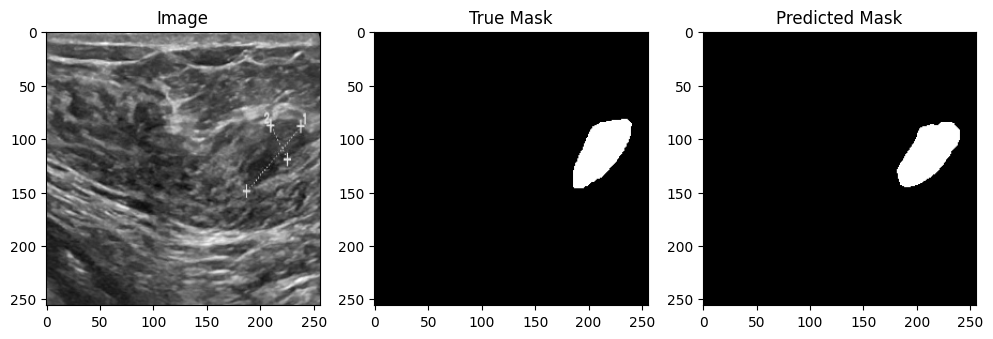

In [17]:
sample_idx = val_df[val_df['label'] != 'normal'].index[0]
row_pos = val_df.index.get_loc(sample_idx)

img, mask, label = val_ds[row_pos]
with torch.no_grad():
    pred = seg_model(img.unsqueeze(0).to(device))
    pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze().numpy()

bbox = get_bbox_from_mask(pred_mask)
print("Bounding box:", bbox, "| True label:", label)

fig, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].imshow(img.squeeze(), cmap='gray'); axs[0].set_title('Image')
axs[1].imshow(mask.squeeze(), cmap='gray'); axs[1].set_title('True Mask')
axs[2].imshow(pred_mask, cmap='gray'); axs[2].set_title('Predicted Mask')
plt.show()

In [18]:
class ClassificationDataset(Dataset):
    def __init__(self, df, seg_model, augment=False):
        self.df = df[df['label'].isin(['benign', 'malignant'])].reset_index(drop=True)
        self.seg_model = seg_model
        self.augment = augment
        self.label_map = {'benign': 0, 'malignant': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_gray = cv2.imread(row['image'], cv2.IMREAD_GRAYSCALE)
        img_gray = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))

        mask = cv2.imread(row['mask'], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        bbox = get_bbox_from_mask((mask > 127).astype(np.float32))

        if bbox is not None:
            x, y, w, h = bbox
            pad = 15
            x1, y1 = max(0, x-pad), max(0, y-pad)
            x2, y2 = min(IMG_SIZE, x+w+pad), min(IMG_SIZE, y+h+pad)
            crop = img_gray[y1:y2, x1:x2]
        else:
            crop = img_gray

        crop = cv2.resize(crop, (224, 224))
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_GRAY2RGB)

        if self.augment and np.random.rand() > 0.5:
            crop_rgb = cv2.flip(crop_rgb, 1)

        crop_rgb = crop_rgb.astype(np.float32) / 255.0
        crop_rgb = (crop_rgb - 0.5) / 0.5
        crop_tensor = torch.tensor(crop_rgb).permute(2, 0, 1)

        label = self.label_map[row['label']]
        return crop_tensor, label

In [19]:
cls_train_ds = ClassificationDataset(train_df, seg_model, augment=True)
cls_val_ds = ClassificationDataset(val_df, seg_model, augment=False)

cls_train_loader = DataLoader(cls_train_ds, batch_size=16, shuffle=True)
cls_val_loader = DataLoader(cls_val_ds, batch_size=16, shuffle=False)

print(len(cls_train_ds), len(cls_val_ds))
crop, lbl = cls_train_ds[0]
print(crop.shape, lbl)

550 97
torch.Size([3, 224, 224]) 0


In [20]:
import torchvision.models as models

cls_model = models.resnet50(weights='IMAGENET1K_V2')
cls_model.fc = nn.Linear(cls_model.fc.in_features, 2)  # benign vs malignant
cls_model = cls_model.to(device)

print("ResNet50 loaded, output classes:", cls_model.fc.out_features)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


ResNet50 loaded, output classes: 2


In [21]:
class_counts = train_df[train_df['label'].isin(['benign','malignant'])]['label'].value_counts()
weights = torch.tensor([1.0/class_counts['benign'], 1.0/class_counts['malignant']], dtype=torch.float32).to(device)
weights = weights / weights.sum() * 2  # normalize

criterion = nn.CrossEntropyLoss(weight=weights)
cls_optimizer = optim.Adam(cls_model.parameters(), lr=1e-4)

In [22]:
from sklearn.metrics import accuracy_score, f1_score

CLS_EPOCHS = 20
best_f1 = 0
CLS_SAVE_PATH = '/content/drive/MyDrive/breast_tumor_project/resnet_cls.pth'

for epoch in range(CLS_EPOCHS):
    cls_model.train()
    train_loss = 0
    for imgs, labels in cls_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        cls_optimizer.zero_grad()
        outputs = cls_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        cls_optimizer.step()
        train_loss += loss.item()

    # validation
    cls_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in cls_val_loader:
            imgs = imgs.to(device)
            outputs = cls_model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{CLS_EPOCHS} | Train Loss: {train_loss/len(cls_train_loader):.4f} | Val Acc: {acc:.4f} | Val F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(cls_model.state_dict(), CLS_SAVE_PATH)
        print(f"  → Saved new best model (F1: {best_f1:.4f})")

Epoch 1/20 | Train Loss: 0.5146 | Val Acc: 0.6804 | Val F1: 0.3404
  → Saved new best model (F1: 0.3404)
Epoch 2/20 | Train Loss: 0.3240 | Val Acc: 0.8144 | Val F1: 0.7000
  → Saved new best model (F1: 0.7000)
Epoch 3/20 | Train Loss: 0.2448 | Val Acc: 0.8144 | Val F1: 0.6667
Epoch 4/20 | Train Loss: 0.2099 | Val Acc: 0.8041 | Val F1: 0.6885
Epoch 5/20 | Train Loss: 0.1531 | Val Acc: 0.8144 | Val F1: 0.7188
  → Saved new best model (F1: 0.7188)
Epoch 6/20 | Train Loss: 0.0849 | Val Acc: 0.8557 | Val F1: 0.7742
  → Saved new best model (F1: 0.7742)
Epoch 7/20 | Train Loss: 0.0823 | Val Acc: 0.8454 | Val F1: 0.7541
Epoch 8/20 | Train Loss: 0.0761 | Val Acc: 0.8351 | Val F1: 0.6923
Epoch 9/20 | Train Loss: 0.0454 | Val Acc: 0.8247 | Val F1: 0.7463
Epoch 10/20 | Train Loss: 0.0544 | Val Acc: 0.8969 | Val F1: 0.8438
  → Saved new best model (F1: 0.8438)
Epoch 11/20 | Train Loss: 0.0658 | Val Acc: 0.8351 | Val F1: 0.7778
Epoch 12/20 | Train Loss: 0.1107 | Val Acc: 0.8763 | Val F1: 0.8125
Epo

In [23]:
seg_model.load_state_dict(torch.load('/content/drive/MyDrive/breast_tumor_project/unet_seg.pth'))
cls_model.load_state_dict(torch.load(CLS_SAVE_PATH))
seg_model.eval()
cls_model.eval()
print("Both best models loaded")

Both best models loaded


In [24]:
def predict_pipeline(image_path):
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_gray = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    img_norm = img_gray.astype(np.float32) / 255.0
    img_tensor = torch.tensor(img_norm).unsqueeze(0).unsqueeze(0).to(device)

    # 1. Segmentation
    with torch.no_grad():
        seg_out = seg_model(img_tensor)
        pred_mask = (torch.sigmoid(seg_out) > 0.5).float().cpu().squeeze().numpy()

    # 2. Detection (bbox)
    bbox = get_bbox_from_mask(pred_mask)
    if bbox is None:
        return {"label": "normal (no tumor detected)", "bbox": None, "confidence": None}

    x, y, w, h = bbox
    pad = 15
    x1, y1 = max(0, x-pad), max(0, y-pad)
    x2, y2 = min(IMG_SIZE, x+w+pad), min(IMG_SIZE, y+h+pad)
    crop = img_gray[y1:y2, x1:x2]
    crop = cv2.resize(crop, (224, 224))
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0
    crop_rgb = (crop_rgb - 0.5) / 0.5
    crop_tensor = torch.tensor(crop_rgb).permute(2,0,1).unsqueeze(0).to(device)

    # 3. Classification
    with torch.no_grad():
        out = cls_model(crop_tensor)
        probs = torch.softmax(out, dim=1).cpu().squeeze().numpy()
        pred_class = np.argmax(probs)

    label_map = {0: 'benign', 1: 'malignant'}
    return {
        "label": label_map[pred_class],
        "bbox": bbox,
        "confidence": float(probs[pred_class])
    }

In [26]:
correct = 0
detected = 0
total = len(val_df)

for idx, row in val_df.iterrows():
    result = predict_pipeline(row['image'])
    if result['bbox'] is not None:
        detected += 1
        if result['label'] == row['label']:
            correct += 1

print(f"Total images: {total}")
print(f"Tumor detected in: {detected} ({detected/total*100:.1f}%)")
print(f"Correctly classified (out of detected): {correct}/{detected} ({correct/detected*100:.1f}%)")

Total images: 117
Tumor detected in: 98 (83.8%)
Correctly classified (out of detected): 78/98 (79.6%)


In [27]:
tumor_df = val_df[val_df['label'] != 'normal']
detected_tumor = 0
correct_tumor = 0

for idx, row in tumor_df.iterrows():
    result = predict_pipeline(row['image'])
    if result['bbox'] is not None:
        detected_tumor += 1
        if result['label'] == row['label']:
            correct_tumor += 1

print(f"Tumor cases: {len(tumor_df)}")
print(f"Detected: {detected_tumor} ({detected_tumor/len(tumor_df)*100:.1f}%)")
print(f"Correctly classified: {correct_tumor}/{detected_tumor} ({correct_tumor/detected_tumor*100:.1f}%)")

normal_df = val_df[val_df['label'] == 'normal']
false_positives = 0
for idx, row in normal_df.iterrows():
    result = predict_pipeline(row['image'])
    if result['bbox'] is not None:
        false_positives += 1

print(f"\nNormal cases: {len(normal_df)}")
print(f"False positives (tumor detected on normal): {false_positives} ({false_positives/len(normal_df)*100:.1f}%)")

Tumor cases: 97
Detected: 92 (94.8%)
Correctly classified: 78/92 (84.8%)

Normal cases: 20
False positives (tumor detected on normal): 6 (30.0%)


              precision    recall  f1-score   support

      benign       0.94      0.91      0.92        66
   malignant       0.82      0.87      0.84        31

    accuracy                           0.90        97
   macro avg       0.88      0.89      0.88        97
weighted avg       0.90      0.90      0.90        97



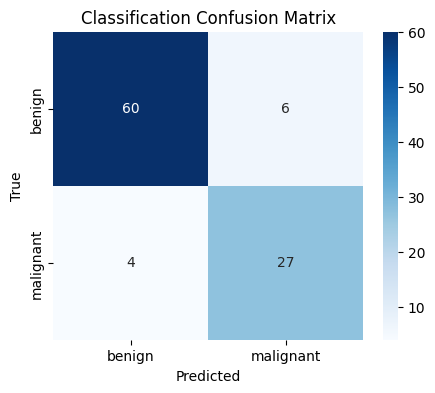


Segmentation Best Val Dice: 0.7869 (Epoch 15)
Classification Best Val F1: 0.8438


In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in cls_val_loader:
        imgs = imgs.to(device)
        outputs = cls_model(imgs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['benign', 'malignant']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['benign','malignant'], yticklabels=['benign','malignant'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Classification Confusion Matrix')
plt.show()

print(f"\nSegmentation Best Val Dice: 0.7869 (Epoch 15)")
print(f"Classification Best Val F1: {best_f1:.4f}")